In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sys.path.append(os.path.abspath("..")) 
from prokaryotic.id_matching import (
    clean_id, parse_gbk_identifiers, parse_eggnog_candidates,
    safe_uniprot_mapping, smart_eggnog_mapping, get_best_mapping,
    calculate_id_metrics
)

ORGANISMS = {
    "bacillus": "B. subtilis",
    "e_coli": "E. coli"
}

ORGANISM_TAXIDS = {
    "e_coli": "562",
    "bacillus": "1423",
}

TOOLS_TO_EVALUATE = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

## 1. Load Data & Parse Annotation Files

For each organism, load the concordant CDS set and parse the Reference, Prokka, Bakta, PGAP, and eggNOG annotation files. All sources are merged on `orf_id` to produce a unified working DataFrame.

In [2]:
parsed_data = {}

for org_id, org_name in ORGANISMS.items():
    print(f"\n{'='*43}")
    print(f"  Loading: {org_name}")
    print(f"{'='*43}\n")

    CONCORDANT_CSV = f"{org_id}_data/{org_id}_concordant_CDS.csv"
    if not os.path.exists(CONCORDANT_CSV):
        print(f"Skipping {org_id}.")
        continue

    df_func = pd.read_csv(CONCORDANT_CSV)
    df_func.drop(
        columns=[c for c in df_func.columns if 'product_' in c or 'Start' in c or 'End' in c or 'Strand' in c],
        inplace=True, errors='ignore'
    )

    df_gbff = parse_gbk_identifiers(f"{org_id}_data/{org_id}_genbank.gbff", "Reference")
    df_prokka = parse_gbk_identifiers(f"../results/prokka/{org_id}_prokka/{org_id}.gbk", "Prokka")
    df_bakta = parse_gbk_identifiers(f"../results/bakta/{org_id}_bakta/{org_id}.gbff", "Bakta")
    df_pgap = parse_gbk_identifiers(f"../results/pgap/{org_id}_pgap/annot.gbk", "PGAP")

    eggnog_candidates = parse_eggnog_candidates(
        f"../results/eggnog/{org_id}_eggnog/{org_id}.emapper.decorated.gff"
    )
    df_func["eggNOG_candidates"] = df_func["orf_id"].map(eggnog_candidates)

    for df in [df_gbff, df_prokka, df_bakta, df_pgap]:
        df_func = pd.merge(df_func, df, on='orf_id', how='left')

    df_func = df_func[df_func['Reference_ID'].notna()]
    parsed_data[org_id] = {'name': org_name, 'df_func': df_func}


  Loading: B. subtilis


  Loading: E. coli



## 2. UniProt ID Mapping

Map tool-specific identifiers to UniProtKB accession numbers. PGAP IDs are resolved via the RefSeq_Protein database. eggNOG IDs use a cascade strategy (STRING -> GI -> Gene Name -> EMBL). Bakta and Prokka IDs are already UniProt-compatible after cleaning.

In [3]:
for org_id, org_data in parsed_data.items():
    df_func = org_data['df_func']
    org_name = org_data['name']

    print(f"\n  UniProt Mapping: {org_name}")
    pgap_raw = df_func['PGAP_ID'].dropna().apply(clean_id).tolist()

    eggnog_raw = []
    for cands in df_func["eggNOG_candidates"].dropna():
        eggnog_raw.extend(cands)
    eggnog_raw = list(set(eggnog_raw))

    df_pgap_uniprot = safe_uniprot_mapping(pgap_raw, from_db='RefSeq_Protein', to_db='UniProtKB')
    df_eggnog_uniprot = smart_eggnog_mapping(eggnog_raw, tax_id=ORGANISM_TAXIDS[org_id])

    dict_pgap = dict(zip(df_pgap_uniprot['From'], df_pgap_uniprot['To'])) if not df_pgap_uniprot.empty else {}
    dict_eggnog = dict(zip(df_eggnog_uniprot['From'], df_eggnog_uniprot['To'])) if not df_eggnog_uniprot.empty else {}

    df_func['UniProt_PGAP'] = df_func['PGAP_ID'].apply(lambda x: dict_pgap.get(clean_id(x), np.nan))
    df_func['UniProt_Bakta'] = df_func['Bakta_ID'].apply(clean_id)
    df_func['UniProt_Prokka'] = df_func['Prokka_ID'].apply(clean_id)
    df_func['UniProt_Reference'] = df_func['Reference_ID'].apply(clean_id)
    df_func['UniProt_eggNOG'] = df_func['eggNOG_candidates'].apply(lambda c: get_best_mapping(c, dict_eggnog))


  UniProt Mapping: B. subtilis
  > Mapping: RefSeq_Protein -> UniProtKB (3704 IDs)...
    -> Success: Mapped 3494 IDs via RefSeq_Protein.
  > Mapping: STRING -> UniProtKB (6684 IDs)...
    -> Success: Mapped 3606 IDs via STRING.
  > Mapping: Gene Name -> UniProtKB (3078 IDs)...
    -> Success: Mapped 303 IDs via Gene Name.
  > Mapping: EMBL/GenBank/DDBJ -> UniProtKB (2959 IDs)...
    -> Success: Mapped 0 IDs via EMBL/GenBank/DDBJ.

  UniProt Mapping: E. coli
  > Mapping: RefSeq_Protein -> UniProtKB (3769 IDs)...
    -> Success: Mapped 4516 IDs via RefSeq_Protein.
  > Mapping: STRING -> UniProtKB (7424 IDs)...
    -> Success: Mapped 1463 IDs via STRING.
  > Mapping: GI number -> UniProtKB (1167 IDs)...
    -> Success: Mapped 1167 IDs via GI number.
  > Mapping: Gene Name -> UniProtKB (4794 IDs)...
    -> Success: Mapped 2736 IDs via Gene Name.
  > Mapping: EMBL/GenBank/DDBJ -> UniProtKB (4089 IDs)...
    -> Success: Mapped 0 IDs via EMBL/GenBank/DDBJ.


## 3. UniRef100 Clustering & Metrics

Map all UniProt accessions to UniRef100 clusters, then compute the Exact UniProt Match Rate and UniRef100 Cluster Match Rate for each tool against the Reference.

In [4]:
all_metrics = {}

for org_id, org_data in parsed_data.items():
    df_func = org_data['df_func']
    org_name = org_data['name']

    print(f"\n  UniRef100 Clustering: {org_name}")
    all_uniprot = list(set(
        df_func['UniProt_Bakta'].dropna().tolist() + df_func['UniProt_Prokka'].dropna().tolist() + 
        df_func['UniProt_Reference'].dropna().tolist() + df_func['UniProt_PGAP'].dropna().tolist() + 
        df_func['UniProt_eggNOG'].dropna().tolist()
    ))

    df_uniref = safe_uniprot_mapping(all_uniprot, from_db='UniProtKB_AC-ID', to_db='UniRef100')
    dict_uniref = dict(zip(df_uniref['From'], df_uniref['To'])) if not df_uniref.empty else {}

    for tool in ['PGAP', 'eggNOG', 'Bakta', 'Prokka', 'Reference']:
        df_func[f'Cluster_{tool}'] = df_func[f'UniProt_{tool}'].apply(lambda x: dict_uniref.get(x, np.nan))

    df_metrics = calculate_id_metrics(df_func, tools=TOOLS_TO_EVALUATE)
    all_metrics[org_id] = {'name': org_name, 'metrics': df_metrics}

    display(df_metrics.style.background_gradient(cmap='Blues', subset=['Exact UniProt Rate (%)', 'UniRef100 Cluster Rate (%)']))


  UniRef100 Clustering: B. subtilis
  > Mapping: UniProtKB_AC-ID -> UniRef100 (4428 IDs)...
    -> Success: Mapped 4428 IDs via UniProtKB_AC-ID.


,Annotation Tool,Exact UniProt Rate (%),UniRef100 Cluster Rate (%),Ref. IDs Available (100%),UniProt Matches (n),Cluster Matches (n)
0,Prokka,44.720000,44.720000,3705,1657,1657
1,Bakta,99.460000,99.510000,3705,3685,3687
2,PGAP,87.910000,88.120000,3705,3257,3265
3,eggNOG,97.330000,97.600000,3705,3606,3616



  UniRef100 Clustering: E. coli
  > Mapping: UniProtKB_AC-ID -> UniRef100 (5743 IDs)...
    -> Success: Mapped 5743 IDs via UniProtKB_AC-ID.


,Annotation Tool,Exact UniProt Rate (%),UniRef100 Cluster Rate (%),Ref. IDs Available (100%),UniProt Matches (n),Cluster Matches (n)
0,Prokka,74.760000,75.840000,3787,2831,2872
1,Bakta,97.070000,97.570000,3787,3676,3695
2,PGAP,67.100000,87.330000,3787,2541,3307
3,eggNOG,32.770000,41.540000,3787,1241,1573


## 4. Visualization

Bar charts comparing Exact UniProt Match Rate and UniRef100 Cluster Match Rate across all annotation tools for each organism.

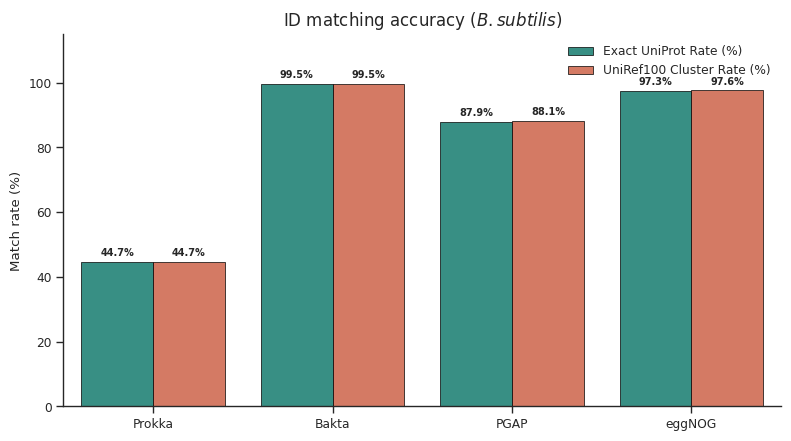

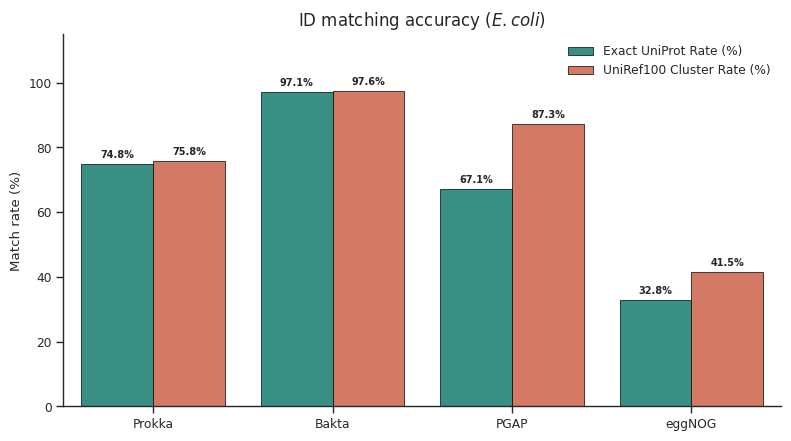

In [5]:
sns.set_theme(style="ticks", context="paper")

for org_id, org_data in all_metrics.items():
    df_metrics = org_data['metrics']
    org_name = org_data['name']

    melted = df_metrics.melt(
        id_vars='Annotation Tool',
        value_vars=['Exact UniProt Rate (%)', 'UniRef100 Cluster Rate (%)'],
        var_name='Metric', value_name='Rate'
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    bars = sns.barplot(
        data=melted,
        x="Annotation Tool",
        y="Rate",
        hue="Metric",
        palette=['#2a9d8f', '#e76f51'],
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=7, fontweight='bold')

    ax.set_ylim(0, 115)
    ax.set_ylabel("Match rate (%)")
    ax.set_xlabel("")
    ax.set_title(
        f"ID matching accuracy ($\\it{{{org_name}}}$)",
        fontsize=12,
    )

    sns.despine(ax=ax)

    ax.legend(
        title="",
        frameon=False,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()